<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>SVM on Breast Cancer Dataset</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Apply SVM on a real-world dataset - the Breast Cancer dataset.</li>
<li>Perform basic EDA and preprocessing (scaling).</li>
<li>Train an SVM classifier and evaluate its performance.</li>
<li>Understand why feature scaling matters for SVM.</li>
<li>Visualize the decision boundary using two features.</li>
</ol>
In the previous notebooks, I built intuition and implemented SVM from scratch 
on synthetic data. Now, I'll use it on a real dataset to see how it performs 
on an actual classification problem.
</div>

In [1]:
# Importing all the libraries needed for this notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Loading the dataset
data = load_breast_cancer()

# Converting to a DataFrame 
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Shape of data:", df.shape)
print("\nTarget classes:", data.target_names)
df.head()

Shape of data: (569, 31)

Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Missing values in each column:

0 total missing values

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


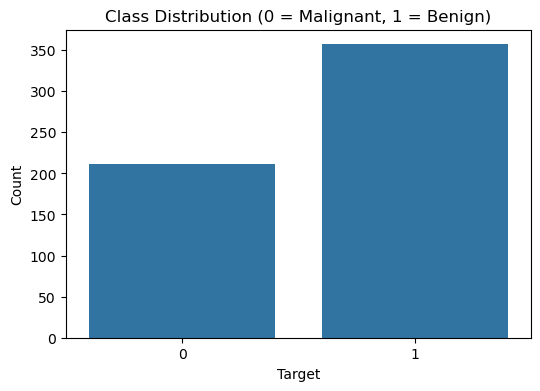

In [3]:
# Checking for missing values
print("Missing values in each column:\n")
print(df.isnull().sum().sum(), "total missing values")

# Checking class distribution
print("\nClass distribution:")
print(df['target'].value_counts())

# Visualizing class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title("Class Distribution (0 = Malignant, 1 = Benign)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [5]:
# Separating features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Splitting into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why Feature Scaling Matters for SVM</b>
</h2>
<div style="font-family:'Times New Roman';">
SVM tries to find the maximum margin hyperplane based on 
<b>distances</b> between points (it relies on dot products). 
<br><br>
If one feature has values ranging from 0-1 and another ranges 
from 0-1000, the larger feature will dominate the distance 
calculation - even if it's not actually more important.
<br><br>
To fix this, I'll use <b>StandardScaler</b> to bring all features 
to a similar scale (mean = 0, standard deviation = 1).
</div>

In [6]:
# Creating a scaler and fitting it ONLY on training data
# (to avoid data leakage from the test set)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling - mean of first feature:", X_train.iloc[:, 0].mean())
print("After scaling - mean of first feature:", X_train_scaled[:, 0].mean())

Before scaling - mean of first feature: 14.117635164835166
After scaling - mean of first feature: -1.811493568091684e-15


In [7]:
# Creating and training the SVM model with a linear kernel
model = SVC(kernel='linear', C=1.0, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Making Predictions and Evaluating the Model</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's now use the trained model to predict on the test set, 
and check how well it performs using:
<ul>
<li><b>Accuracy</b> - overall correctness of predictions.</li>
<li><b>Confusion Matrix</b> - breakdown of correct/incorrect predictions per class.</li>
<li><b>Classification Report</b> - precision, recall, and F1-score.</li>
</ul>
</div>

In [8]:
# Making predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# Printing classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 95.61%

Classification Report:

              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



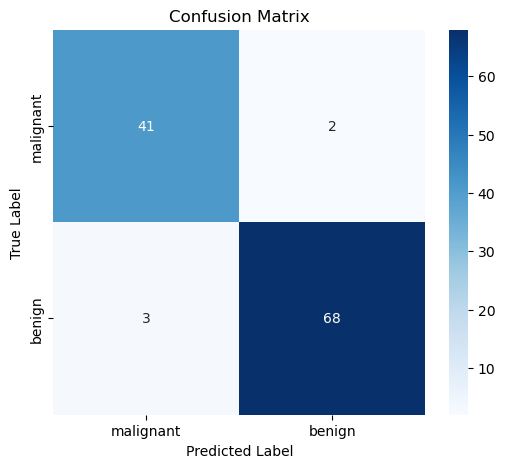

In [9]:
# Computing the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualizing it as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

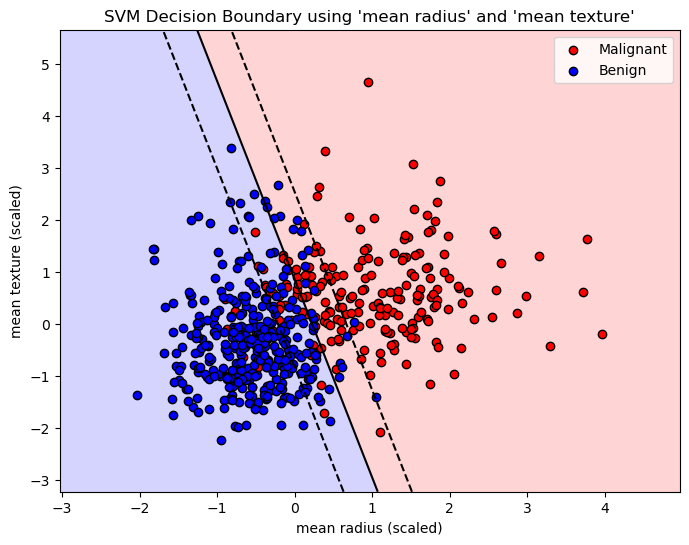

In [10]:
# Picking two features for visualization
feature1 = 'mean radius'
feature2 = 'mean texture'

X_2d = df[[feature1, feature2]].values
y_2d = df['target'].values

# Scaling these two features
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Training a new SVM on just these 2 features
model_2d = SVC(kernel='linear', C=1.0)
model_2d.fit(X_2d_scaled, y_2d)

# Creating a mesh grid to plot the decision boundary
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))

# Getting decision function values for the grid
Z = model_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=[-1e6, 0, 1e6], colors=['#FFAAAA', '#AAAAFF'], alpha=0.5)
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1],
            linestyles=['--', '-', '--'])

# Plotting actual data points
plt.scatter(X_2d_scaled[y_2d == 0][:, 0], X_2d_scaled[y_2d == 0][:, 1],
            color='red', label='Malignant', edgecolors='k')
plt.scatter(X_2d_scaled[y_2d == 1][:, 0], X_2d_scaled[y_2d == 1][:, 1],
            color='blue', label='Benign', edgecolors='k')

plt.title(f"SVM Decision Boundary using '{feature1}' and '{feature2}'")
plt.xlabel(feature1 + " (scaled)")
plt.ylabel(feature2 + " (scaled)")
plt.legend()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Applied SVM on the real <b>Breast Cancer dataset</b> using sklearn.</li>
<li>Saw why <b>feature scaling</b> is important before training an SVM.</li>
<li>Evaluated the model using <b>accuracy, confusion matrix, and classification report</b>.</li>
<li>Visualized the <b>decision boundary, margins</b> on real data using just 2 features 
- connecting it back to the intuition from the first two notebooks.</li>
</ul>
The full model (using all 30 features) performed quite well, showing that 
even a simple linear SVM can be very effective on real-world medical data.
<br><br>